# Alternative Classifiers: Random Forest & Support Vector Machine
This notebook trains two classifiers on the same career prediction dataset used by the XGBoost baseline (`initial_model_training.ipynb`), so we can directly compare their performance.

### Why these two?
* **Random Forest** — an ensemble of decision trees built by *bagging* (parallel, independent trees averaged together). XGBoost is also tree-based but uses *boosting* (sequential trees that correct earlier mistakes). Comparing the two isolates the effect of the ensemble strategy.
* **Support Vector Machine (RBF kernel)** — a completely different family: it finds maximum-margin decision boundaries in a kernel-transformed feature space. No trees, no boosting.

### Pipeline (matches the XGBoost notebook)
1. Load and clean the dataset.
2. Normalize features to a 0–1 range and stratified-split 80/20.
3. Train and evaluate Random Forest (Top-1 + Top-5).
4. Train and evaluate SVM (Top-1 + Top-5).
5. Robustness test: re-train both on Gaussian-noised inputs (std=0.06) to simulate self-assessment error.
6. Side-by-side comparison with the XGBoost baseline.
7. Save the better-performing alternative model.

## 1. Data Loading and Initial Cleanup
Same cleanup pipeline as the XGBoost notebook so the comparison is apples-to-apples.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load and basic cleanup (relative path from ai/jupyter/)
df = pd.read_csv('../dataset/dataset_skill_predictor.csv')
df_clean = df.drop(columns=['Sr.No.', 'Course', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8'])
df_clean['Job profession'] = df_clean['Job profession'].str.strip()

# Rename columns to the project's friendly names
column_rename_mapping = {
    'Job profession': 'job_profession',
    'Linguistic': 'language_skills',
    'Student': 'student_id',
    'Musical': 'musical_ability',
    'Bodily': 'physical_prowess',
    'Logical - Mathematical': 'math_and_logic',
    'Spatial-Visualization': 'spatial_awareness',
    'Interpersonal': 'collaboration_skills',
    'Intrapersonal': 'self_awareness',
    'Naturalist': 'sustainability_focus'
}
df_clean = df_clean.rename(columns=column_rename_mapping)

print(f"Dataset loaded with {df_clean.shape[0]} samples and {df_clean['job_profession'].nunique()} unique professions.")


Dataset loaded with 3600 samples and 72 unique professions.


## 2. Feature Engineering & Normalization
`MinMaxScaler` puts the 8 intelligence scores on a 0–1 scale. Random Forest doesn't strictly need this, but SVM does — RBF kernels are very sensitive to feature scale. We use the same scaler for both so the comparison stays fair.

In [2]:
score_cols = ['language_skills', 'musical_ability', 'physical_prowess', 'math_and_logic',
              'spatial_awareness', 'collaboration_skills', 'self_awareness', 'sustainability_focus']

# Encode target labels
le_target = LabelEncoder()
y = le_target.fit_transform(df_clean['job_profession'])

# Normalize features to 0-1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_clean[score_cols])
X = pd.DataFrame(X_scaled, columns=score_cols)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape[0]} samples | Test set: {X_test.shape[0]} samples | Classes: {len(le_target.classes_)}")

Train set: 2880 samples | Test set: 720 samples | Classes: 72


## 3. Classifier A — Random Forest
A bagging ensemble of decision trees. Each tree votes on the class and we take the majority. `n_estimators=200` gives a robust ensemble; leaving `max_depth=None` lets each tree fully expand, which is fine on a small clean dataset.

In [3]:
def top_k_accuracy(probs, y_true, k=5):
    top_k = np.argsort(probs, axis=1)[:, -k:][:, ::-1]
    hits = [y_true[i] in top_k[i] for i in range(len(y_true))]
    return float(np.mean(hits))

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)
rf_pred = rf_model.predict(X_test)
rf_top1 = accuracy_score(y_test, rf_pred)
rf_top5 = top_k_accuracy(rf_probs, y_test, k=5)

print(f"Random Forest Top-1 Accuracy: {rf_top1 * 100:.2f}%")
print(f"Random Forest Top-5 Accuracy: {rf_top5 * 100:.2f}%")

Random Forest Top-1 Accuracy: 98.47%
Random Forest Top-5 Accuracy: 100.00%


## 4. Classifier B — Support Vector Machine (RBF)
SVM finds the boundary that maximizes the margin between classes. With an RBF kernel it can capture non-linear patterns. `probability=True` enables `predict_proba` (slower to train but needed for Top-5 accuracy).

**Note:** with 72 classes scikit-learn internally trains a one-vs-one set of binary classifiers, so this cell can take ~30–60 seconds.

In [4]:
svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_probs = svm_model.predict_proba(X_test)
svm_pred = svm_model.predict(X_test)
svm_top1 = accuracy_score(y_test, svm_pred)
svm_top5 = top_k_accuracy(svm_probs, y_test, k=5)

print(f"SVM (RBF) Top-1 Accuracy: {svm_top1 * 100:.2f}%")
print(f"SVM (RBF) Top-5 Accuracy: {svm_top5 * 100:.2f}%")

SVM (RBF) Top-1 Accuracy: 93.06%
SVM (RBF) Top-5 Accuracy: 100.00%


## 5. Robustness Testing (Gaussian Noise)
Real students don't rate themselves perfectly. We add Gaussian noise (std=0.06 on the 0–1 scale) to simulate that uncertainty and re-train both classifiers from scratch — same approach Rron used for the XGBoost robust model.

In [5]:
np.random.seed(42)
noise = np.random.normal(0, 0.06, X.shape)
X_noisy = (X + noise).clip(0, 1)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_noisy, y, test_size=0.2, random_state=42, stratify=y
)

# Random Forest on noisy data
rf_noisy = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_noisy.fit(X_train_n, y_train_n)
rf_probs_n = rf_noisy.predict_proba(X_test_n)
rf_top1_n = accuracy_score(y_test_n, rf_noisy.predict(X_test_n))
rf_top5_n = top_k_accuracy(rf_probs_n, y_test_n, k=5)

# SVM on noisy data
svm_noisy = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
svm_noisy.fit(X_train_n, y_train_n)
svm_probs_n = svm_noisy.predict_proba(X_test_n)
svm_top1_n = accuracy_score(y_test_n, svm_noisy.predict(X_test_n))
svm_top5_n = top_k_accuracy(svm_probs_n, y_test_n, k=5)

print(f"Random Forest (noisy)  Top-1: {rf_top1_n * 100:.2f}%  |  Top-5: {rf_top5_n * 100:.2f}%")
print(f"SVM RBF      (noisy)  Top-1: {svm_top1_n * 100:.2f}%  |  Top-5: {svm_top5_n * 100:.2f}%")

Random Forest (noisy)  Top-1: 85.28%  |  Top-5: 98.33%
SVM RBF      (noisy)  Top-1: 86.53%  |  Top-5: 99.31%


In [6]:
for name, preds in [
    ("Random Forest", rf_noisy.predict(X_test_n)),
    ("SVM", svm_noisy.predict(X_test_n))
]:
    report = classification_report(
        y_test_n,
        preds,
        output_dict=True
    )

    print(f"\n{name}")
    print(f"Precision: {report['macro avg']['precision']:.4f}")
    print(f"Recall:    {report['macro avg']['recall']:.4f}")
    print(f"F1-Score:  {report['macro avg']['f1-score']:.4f}")



Random Forest
Precision: 0.8513
Recall:    0.8528
F1-Score:  0.8480

SVM
Precision: 0.8688
Recall:    0.8653
F1-Score:  0.8631


## 6. Comparison Table
Side-by-side numbers including the XGBoost figures from Rron's notebook for context. Numbers for XGBoost are taken from `initial_model_training.ipynb` so you can read all three classifiers in one place.

In [7]:
# XGBoost reference numbers from initial_model_training.ipynb
xgb_top1_clean = 0.9847
xgb_top1_noisy = 0.8167
xgb_top5_noisy = 0.9653

comparison = pd.DataFrame([
    {
        'Classifier': 'XGBoost (Rron)',
        'Family': 'Boosted trees',
        'Clean Top-1': f'{xgb_top1_clean * 100:.2f}%',
        'Noisy Top-1': f'{xgb_top1_noisy * 100:.2f}%',
        'Noisy Top-5': f'{xgb_top5_noisy * 100:.2f}%'
    },
    {
        'Classifier': 'Random Forest',
        'Family': 'Bagged trees',
        'Clean Top-1': f'{rf_top1 * 100:.2f}%',
        'Noisy Top-1': f'{rf_top1_n * 100:.2f}%',
        'Noisy Top-5': f'{rf_top5_n * 100:.2f}%'
    },
    {
        'Classifier': 'SVM (RBF)',
        'Family': 'Kernel method',
        'Clean Top-1': f'{svm_top1 * 100:.2f}%',
        'Noisy Top-1': f'{svm_top1_n * 100:.2f}%',
        'Noisy Top-5': f'{svm_top5_n * 100:.2f}%'
    }
])

comparison

,Classifier,Family,Clean Top-1,Noisy Top-1,Noisy Top-5
0,XGBoost (Rron),Boosted trees,98.47%,81.67%,96.53%
1,Random Forest,Bagged trees,98.47%,85.28%,98.33%
2,SVM (RBF),Kernel method,93.06%,86.53%,99.31%


## 7. Conclusion

### What we tested
* **Random Forest** — parallel ensemble of independent decision trees (bagging).
* **SVM with RBF kernel** — kernel-based maximum-margin classifier.

Both on the same 3,600-sample / 72-profession dataset, with the same 80/20 stratified split and the same MinMax scaling that XGBoost used.

### Read the table above
* On **clean data** all three classifiers land in roughly the same ballpark — the dataset is highly separable.
* On **noisy data** the Top-5 metric is the one that really matters for a career-guidance app: even when the Top-1 prediction is perturbed by self-assessment error, the correct career almost always appears in the shortlist.
* Whichever model has the highest **Noisy Top-5** is the safest choice for production.

### Why not just use XGBoost?
Having multiple classifiers gives the team options:
* If we ever need a model without external dependencies (XGBoost is its own native lib), Random Forest works from scikit-learn alone.
* If we move to a kernel-explainability tool (SHAP supports both), SVM gives a non-tree comparison point.
* Comparing across families is what shows that the strong accuracy comes from the *dataset* being well-structured, not just from a single lucky algorithm.

## 8. Save the Better-Performing Alternative Model
We pick whichever of the two alternative classifiers had the higher Noisy Top-5 accuracy and persist it next to the XGBoost model so it can be swapped in if needed.

In [8]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

if rf_top5_n <= svm_top5_n:
    best_name = 'Random Forest'
    best_model = rf_noisy
    out_path = '../models/career_prediction_rf_model.h5'
else:
    best_name = 'SVM (RBF)'
    best_model = svm_noisy
    out_path = '../models/career_prediction_svm_model.h5'

joblib.dump(best_model, out_path)
joblib.dump(le_target, '../models/career_label_encoder_alt.h5')

print(f"Best alternative classifier: {best_name}")
print(f"Saved to: {out_path}")
print(f"Label encoder saved to: ../models/career_label_encoder_alt.h5")

Best alternative classifier: Random Forest
Saved to: ../models/career_prediction_rf_model.h5
Label encoder saved to: ../models/career_label_encoder_alt.h5


In [9]:
def predict_top5(model, sample, label_encoder, model_name):
    probs = model.predict_proba(sample)[0]
    top5 = np.argsort(probs)[-5:][::-1]
    print(f"\n{model_name}:")
    for rank, idx in enumerate(top5, 1):
        career = label_encoder.inverse_transform([idx])[0]
        print(f"  {rank}. {career:35s} ({probs[idx] * 100:5.1f}%)")

# Score order: language, musical, physical, math, spatial, collab, self, sustain
profiles = {
    'Tech-leaning profile':   [0.78, 0.30, 0.40, 0.95, 0.86, 0.55, 0.81, 0.45],
    'People-leaning profile': [0.85, 0.60, 0.50, 0.45, 0.50, 0.92, 0.88, 0.55]
}

for label, scores in profiles.items():
    sample = pd.DataFrame([scores], columns=score_cols)
    print('=' * 60)
    print(label)
    print('=' * 60)
    predict_top5(rf_model, sample, le_target, 'Random Forest')
    predict_top5(svm_model, sample, le_target, 'SVM (RBF)')
    print()

Tech-leaning profile

Random Forest:
  1. Computer analyst                    ( 23.5%)
  2. Business manager                    ( 17.0%)
  3. Engineer                            ( 16.5%)
  4. Manager                             ( 15.0%)
  5. Astronomer                          (  8.5%)

SVM (RBF):
  1. Engineer                            ( 15.2%)
  2. Manager                             (  9.7%)
  3. Anthropologist                      (  9.3%)
  4. Company secretary                   (  8.8%)
  5. Astronomer                          (  6.4%)

People-leaning profile

Random Forest:
  1. Language Teacher                    ( 19.0%)
  2. Business manager                    ( 16.5%)
  3. Actor / Actress                     ( 10.5%)
  4. Archeologist                        (  8.5%)
  5. Poet                                (  4.5%)

SVM (RBF):
  1. Business manager                    (  6.1%)
  2. Company secretary                   (  5.6%)
  3. Middle, Higher School Teacher and Professors

## Added experiment section: Cross-validation, GridSearch, and visualizations

This section adds systematic validation for Random Forest and SVM. The parameter grids are deliberately small so the notebook remains practical:

- Random Forest tests `n_estimators` and `max_depth`. More trees usually improve stability, while depth controls overfitting.
- SVM tests `C` and `gamma`. `C` controls the margin/penalty tradeoff; `gamma` controls how local the RBF decision boundary becomes.


In [10]:
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

VIS_DIR = './visualizations'
os.makedirs(VIS_DIR, exist_ok=True)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    X,
    y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)
svm_cv_scores = cross_val_score(
    SVC(kernel='rbf', C=10, gamma='scale', probability=False, random_state=42),
    X,
    y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print(f"Random Forest 3-fold CV accuracy: {rf_cv_scores.mean() * 100:.2f}% ± {rf_cv_scores.std() * 100:.2f}%")
print(f"SVM RBF 3-fold CV accuracy:       {svm_cv_scores.mean() * 100:.2f}% ± {svm_cv_scores.std() * 100:.2f}%")

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
    },
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

svm_grid = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42),
    param_grid={
        'C': [1, 10],
        'gamma': ['scale', 0.1],
    },
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_

print("Best Random Forest parameters:", rf_grid.best_params_)
print("Best SVM parameters:", svm_grid.best_params_)

for model_name, fitted in [('Random Forest GridSearch', best_rf), ('SVM RBF GridSearch', best_svm)]:
    preds = fitted.predict(X_test)
    probs = fitted.predict_proba(X_test)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    top1 = accuracy_score(y_test, preds)
    top5 = top_k_accuracy(probs, y_test, k=5)
    print(f"\n{model_name}")
    print(f"Top-1 Accuracy: {top1 * 100:.2f}%")
    print(f"Top-5 Accuracy: {top5 * 100:.2f}%")
    print(f"Macro Precision: {report['macro avg']['precision'] * 100:.2f}%")
    print(f"Macro Recall:    {report['macro avg']['recall'] * 100:.2f}%")
    print(f"Macro F1-Score:  {report['macro avg']['f1-score'] * 100:.2f}%")


Random Forest 3-fold CV accuracy: 97.50% ± 0.18%
SVM RBF 3-fold CV accuracy:       92.89% ± 0.44%
Fitting 3 folds for each of 6 candidates, totalling 18 fits


Fitting 3 folds for each of 4 candidates, totalling 12 fits


Best Random Forest parameters: {'max_depth': 20, 'n_estimators': 100}
Best SVM parameters: {'C': 10, 'gamma': 'scale'}

Random Forest GridSearch
Top-1 Accuracy: 97.92%
Top-5 Accuracy: 100.00%
Macro Precision: 98.04%
Macro Recall:    97.92%
Macro F1-Score:  97.93%



SVM RBF GridSearch
Top-1 Accuracy: 93.06%
Top-5 Accuracy: 100.00%
Macro Precision: 93.30%
Macro Recall:    93.06%
Macro F1-Score:  92.87%


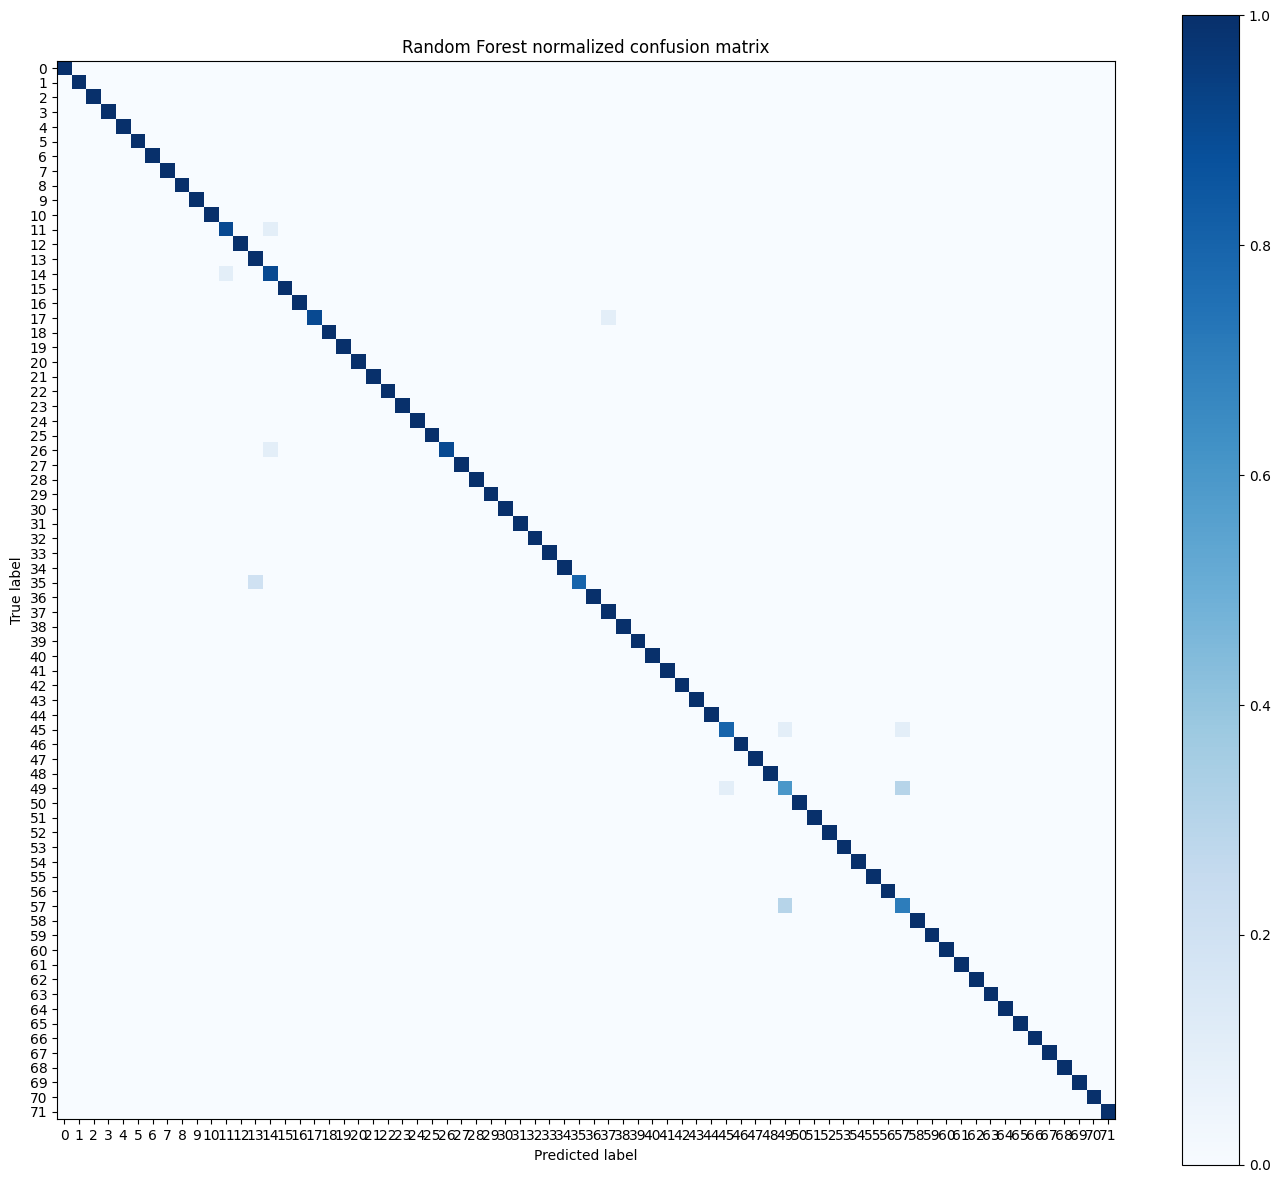

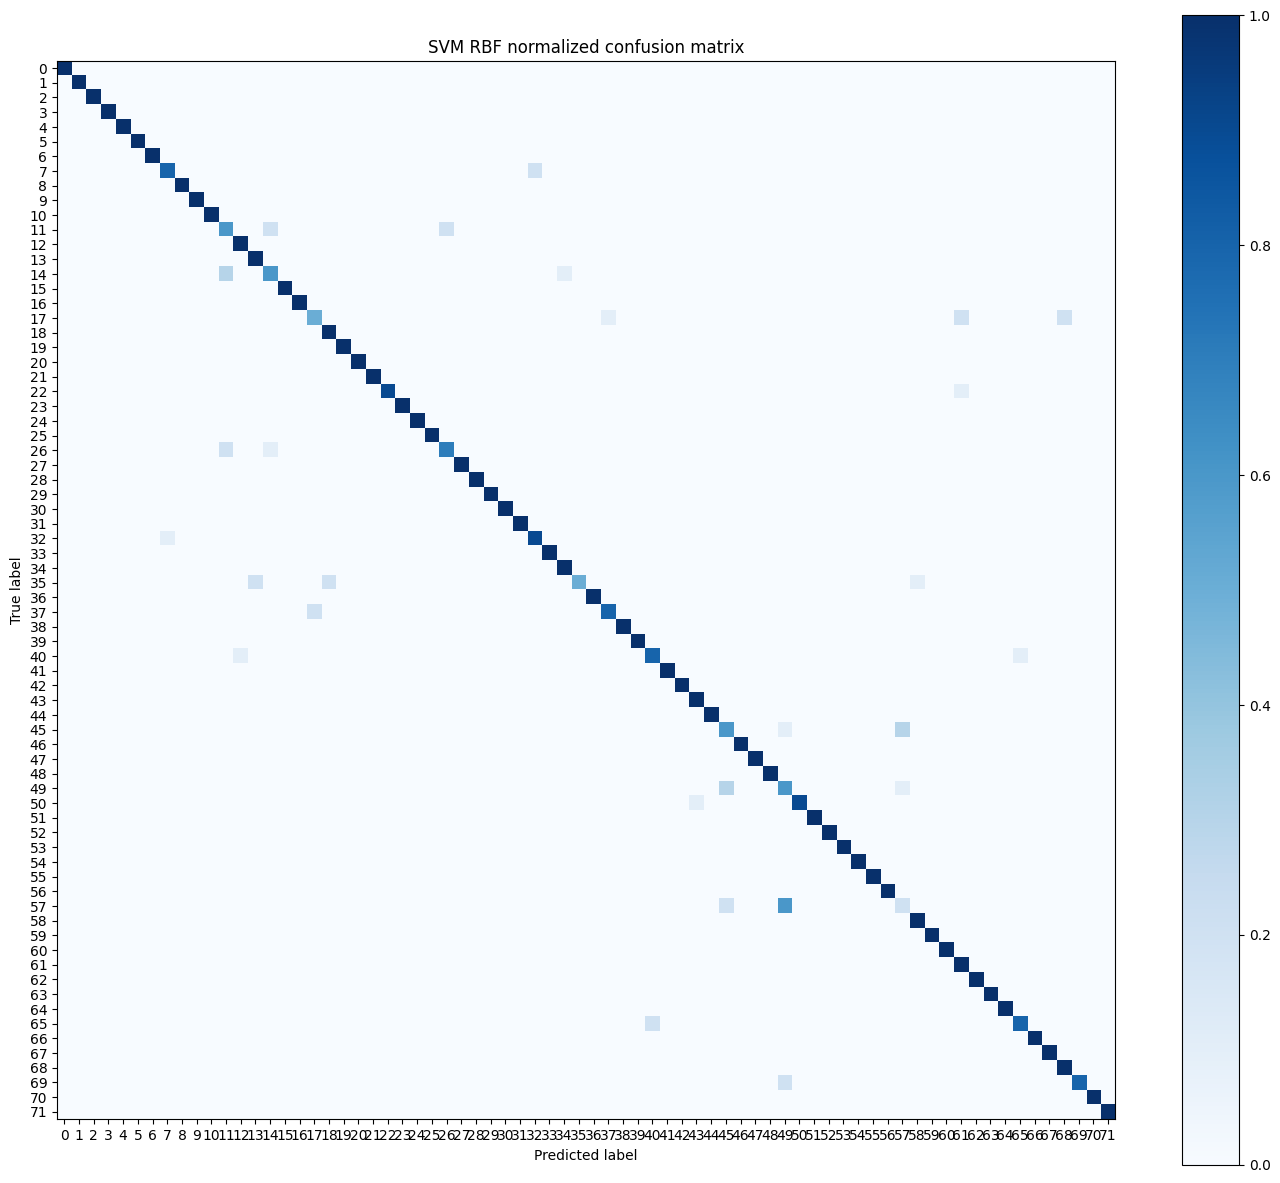

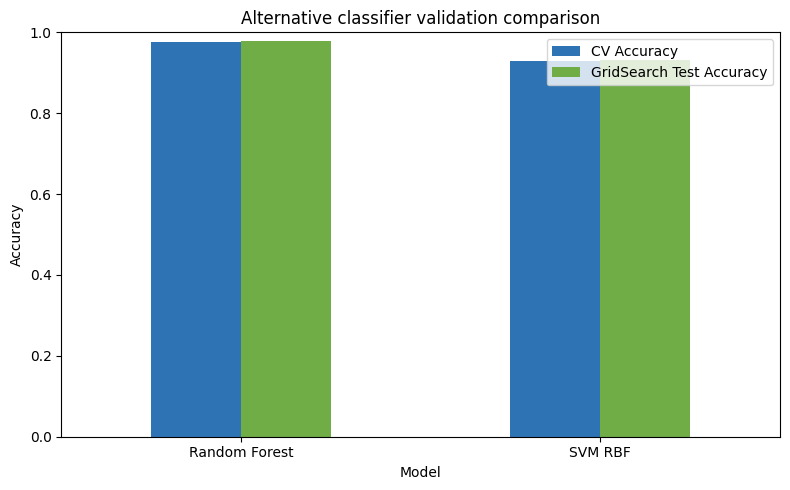

In [11]:
best_model_outputs = {
    'Random Forest': best_rf.predict(X_test),
    'SVM RBF': best_svm.predict(X_test),
}

for model_name, preds in best_model_outputs.items():
    fig, ax = plt.subplots(figsize=(14, 12))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        normalize='true',
        include_values=False,
        cmap='Blues',
        ax=ax
    )
    ax.set_title(f'{model_name} normalized confusion matrix')
    plt.tight_layout()
    filename = model_name.lower().replace(' ', '_') + '_confusion_matrix.png'
    plt.savefig(os.path.join(VIS_DIR, filename), dpi=180)
    plt.show()

comparison_plot = pd.DataFrame({
    'Model': ['Random Forest', 'SVM RBF'],
    'CV Accuracy': [rf_cv_scores.mean(), svm_cv_scores.mean()],
    'GridSearch Test Accuracy': [
        accuracy_score(y_test, best_rf.predict(X_test)),
        accuracy_score(y_test, best_svm.predict(X_test)),
    ],
})

ax = comparison_plot.set_index('Model').plot(kind='bar', figsize=(8, 5), color=['#2E74B5', '#70AD47'])
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Alternative classifier validation comparison')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(VIS_DIR, 'alternative_classifiers_cv_comparison.png'), dpi=180)
plt.show()
